Name: Rakesh Yadav

Roll No.: 4012

In [1]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.6 MB/s eta 0:00:00


In [2]:
!pip install qiskit[visualization]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 818.4 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=b7f0a4825cc714731dd5da999430b1aa4c3f2ffd962dff73e7e78bf73e282bf2
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [3]:
# Import required libraries
from qiskit import *
from qiskit.visualization import plot_bloch_multivector, plot_histogram
#from qiskit_textbook.tools import array_to_latex
#from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

In [4]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 48.1 MB/s eta 0:00:00


In [5]:
#Step 2: Define the Oracle for Marking |11⟩ as the Solution
def grover_oracle(circuit):
    circuit.cz(0, 1)  # Flip sign of |11⟩


In [6]:
#Step 3: Define the Diffuser
def diffuser(circuit):
    circuit.h([0, 1])
    circuit.x([0, 1])
    circuit.h(1)
    circuit.cx(0, 1)
    circuit.h(1)
    circuit.x([0, 1])
    circuit.h([0, 1])


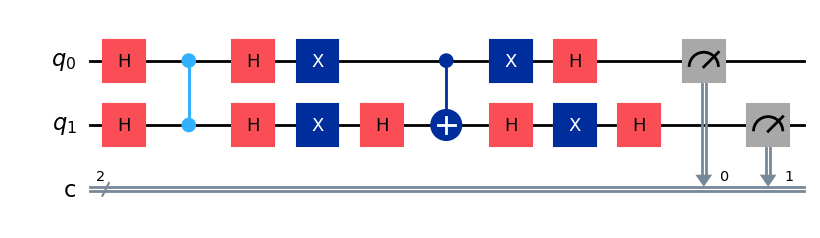

In [7]:
#Step 4: Build the Grover Circuit
qc = QuantumCircuit(2, 2)

# Step 1: Initialize in superposition
qc.h([0, 1])

# Step 2: Apply Oracle
grover_oracle(qc)

# Step 3: Apply Diffuser
diffuser(qc)

# Step 4: Measure
qc.measure([0, 1], [0, 1])
qc.draw('mpl')


In [8]:
from qiskit_aer import Aer

simulator = Aer.get_backend('aer_simulator')
compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=1024)

# Get results
result = job.result()
counts = result.get_counts()
print(counts)
plot_histogram(counts)
plt.show()

{'11': 1024}
